#**Izaz Khan**
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN Lab 09

***Date:*** 05/04/2026

#**Task 1**
##**Data Understanding**

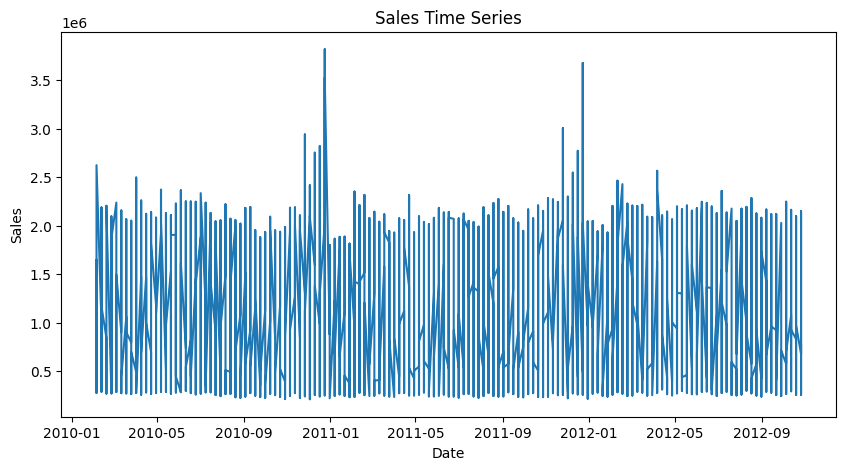

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('/content/Walmart.csv')  # adjust file name

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
df = df.sort_values('Date')

# Use weekly_sales or similar column
sales = df['Weekly_Sales']

# Plot time series
plt.figure(figsize=(10,5))
plt.plot(df['Date'], sales)
plt.title("Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

#**Task 2  Preprocessing**
##**Normalize & Sequence Creation**

In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Normalize
scaler = MinMaxScaler()
sales_scaled = scaler.fit_transform(sales.values.reshape(-1,1))

# Function to create sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(sales_scaled, window_size)

# Train-test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#**Task 3 LSTM Model**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(window_size,1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(X_train, y_train,
                    epochs=20,
                    validation_data=(X_test, y_test))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0286 - val_loss: 0.0224
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0250 - val_loss: 0.0223
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0251 - val_loss: 0.0224
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0251 - val_loss: 0.0222
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0250 - val_loss: 0.0221
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0250 - val_loss: 0.0221
Epoch 7/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0250 - val_loss: 0.0222
Epoch 8/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0250 - val_loss: 0.0221
Epoch 9/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0250 - val_loss: 0.0220
Epoch 10/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0250 - val_loss: 0.0220
Epoch 11/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0249 - val_loss: 0.0222
Epoch 12/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.

#**Task 4 Parameter Modification**
##**Modified Model (Example: change units + add dropout)**

In [ ]:
from tensorflow.keras.layers import Dropout

model_mod = Sequential()
model_mod.add(LSTM(100, activation='relu', input_shape=(window_size,1)))
model_mod.add(Dropout(0.2))
model_mod.add(Dense(1))

model_mod.compile(optimizer='adam', loss='mse')

history_mod = model_mod.fit(X_train, y_train,
                           epochs=20,
                           validation_data=(X_test, y_test))

Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0280 - val_loss: 0.0223
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0254 - val_loss: 0.0222
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0254 - val_loss: 0.0222
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0255 - val_loss: 0.0225
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0253 - val_loss: 0.0220
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0252 - val_loss: 0.0226
Epoch 7/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0251 - val_loss: 0.0220
Epoch 8/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0252 - val_loss: 0.0221
Epoch 9/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0251 - val_loss: 0.0220
Epoch 10/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0251 - val_loss: 0.0220
Epoch 11/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0249 - val_loss: 0.0220
Epoch 12/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

#**Task 5  Forecast Future**
##**Prediction**

In [ ]:
# Predict test data
predictions = model.predict(X_test)

# Inverse scaling
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


##**Plot Actual vs Predicted**

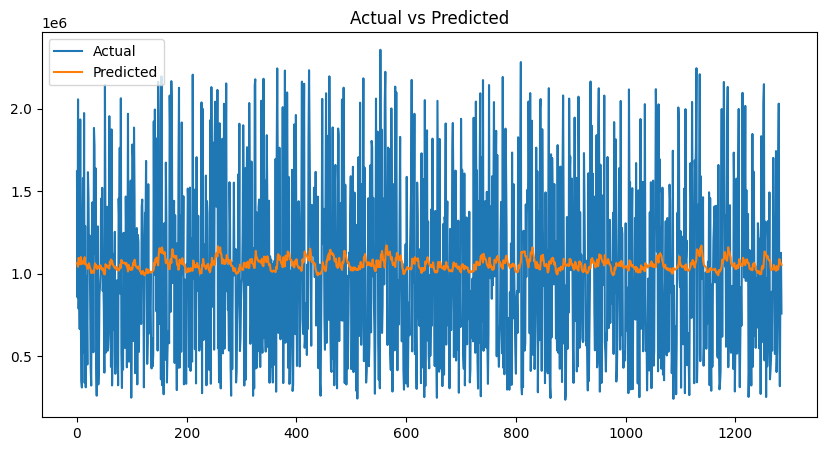

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

#**Loss vs Epoch**

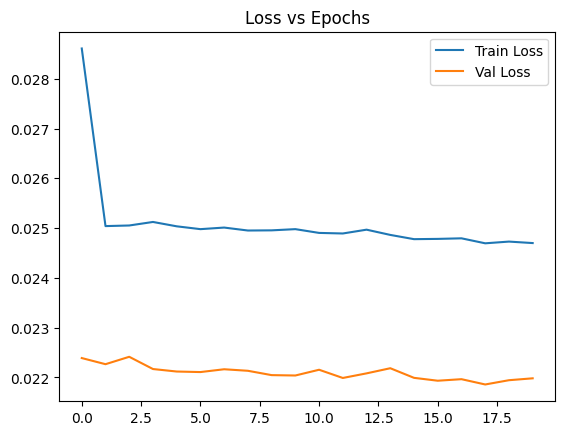

In [ ]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.show()

#**Future Forecast (Next 10 months)**

In [ ]:
future_steps = 10
last_sequence = sales_scaled[-window_size:]
future_predictions = []

current_input = last_sequence.reshape(1, window_size, 1)

for _ in range(future_steps):
    pred = model.predict(current_input)[0]
    future_predictions.append(pred)

    current_input = np.append(current_input[:,1:,:], [[pred]], axis=1)

future_predictions = scaler.inverse_transform(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


#**Plot Future Forecast**

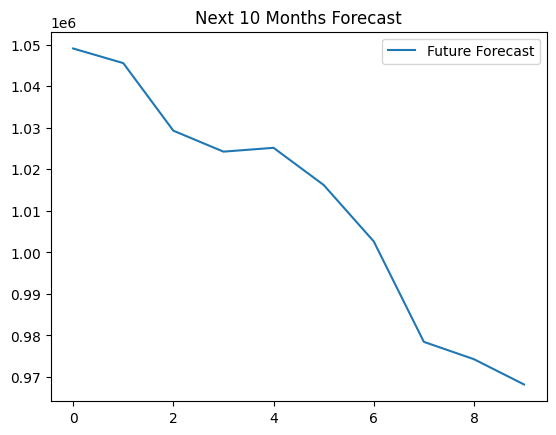

In [ ]:
plt.plot(future_predictions, label="Future Forecast")
plt.legend()
plt.title("Next 10 Months Forecast")
plt.show()

#**What we learned**

Understanding of LSTM (Long Short-Term Memory) for time series forecasting

How to analyze time series data (trend and seasonality)

Importance of data preprocessing (normalization)

Creating input sequences (windowing) for LSTM

Building and training an LSTM model using Keras

Effect of hyperparameters (window size, units, dropout) on performance

How to evaluate model performance using loss metrics

Generating and visualizing future predictions

#**Conclusion**

LSTM models are effective for sequential and time series data

Proper preprocessing improves model accuracy

Parameter tuning helps in reducing overfitting and improving results

The model successfully captures trend and seasonality patterns

LSTM can help businesses make better demand forecasting
decisions

Accurate forecasting can reduce losses and improve planning